## Install Requirements & Download dataset

In [1]:
import os, pathlib, shutil, random
!pip install -q opendatasets
import opendatasets as od
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
if not os.path.exists('./potato-leaf-disease-dataset'):
    print('Downloading Dataset')
    od.download('https://www.kaggle.com/datasets/nirmalsankalana/potato-leaf-disease-dataset')

## Configuration

In [3]:
DATASET_DIR   = './potato-leaf-disease-dataset'
SPLIT_DIR     = './potato_split'
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32
SEED          = 42
VAL_RATIO     = 0.2
EPOCHS = 30
LR    = 1e-3

## Step 1: Inspect Class Distribution

Class distribution:
  Bacteria       : 569
  Fungi          : 748
  Healthy        : 201
  Nematode       : 68
  Pest           : 611
  Phytopthora    : 347
  Virus          : 532
  TOTAL          : 3076


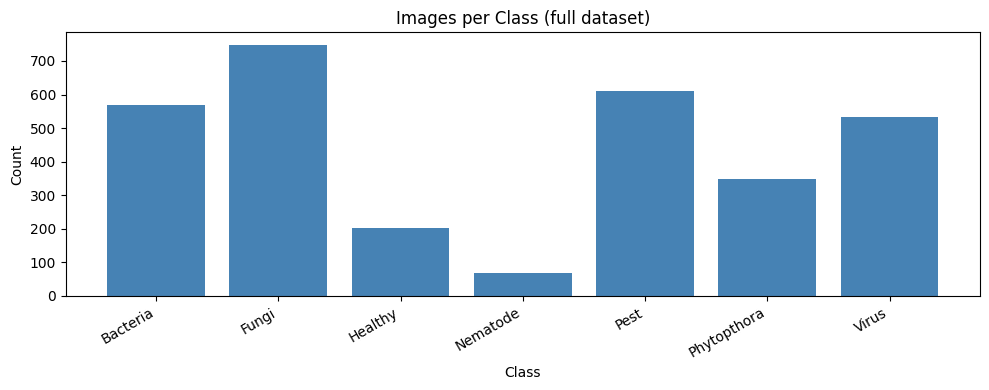

In [5]:
class_counts = {}
for cls in sorted(os.listdir(DATASET_DIR)):
    p = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(p):
        class_counts[cls] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

print('Class distribution:')
for k, v in class_counts.items():
    print(f'  {k:15s}: {v}')
print(f'  TOTAL          : {sum(class_counts.values())}')

plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Images per Class (full dataset)')
plt.xlabel('Class'); plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## Step 2: Train/Val Split

In [6]:
random.seed(SEED)

# Remove old split if exists
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ['train', 'val']:
    for cls in class_counts:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# Symlink (or copy) files into split dirs
for cls in class_counts:
    src_dir = os.path.join(DATASET_DIR, cls)
    files = [
        f for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    random.shuffle(files)
    n_val = max(1, int(len(files) * VAL_RATIO))
    splits = {'val': files[:n_val], 'train': files[n_val:]}
    for split, flist in splits.items():
        for fname in flist:
            src  = os.path.join(src_dir, fname)
            dst  = os.path.join(SPLIT_DIR, split, cls, fname)
            shutil.copy2(src, dst)

# Verify
print('\nSplit summary:')
for split in ['train', 'val']:
    print(f'  {split}:')
    for cls in sorted(os.listdir(os.path.join(SPLIT_DIR, split))):
        n = len(os.listdir(os.path.join(SPLIT_DIR, split, cls)))
        print(f'    {cls:15s}: {n}')


Split summary:
  train:
    Bacteria       : 456
    Fungi          : 599
    Healthy        : 161
    Nematode       : 55
    Pest           : 489
    Phytopthora    : 278
    Virus          : 426
  val:
    Bacteria       : 113
    Fungi          : 149
    Healthy        : 40
    Nematode       : 13
    Pest           : 122
    Phytopthora    : 69
    Virus          : 106


## Step 3: Build tf.data Datasets

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

training_set = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    labels='inferred', label_mode='categorical',
    color_mode='rgb', batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE, shuffle=True, seed=SEED
)

validation_set = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    labels='inferred', label_mode='categorical',
    color_mode='rgb', batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE, shuffle=False
)

class_names = training_set.class_names
NUM_CLASSES  = len(class_names)
print(f'Classes ({NUM_CLASSES}):', class_names)

with open('class.json', 'w') as f:
    json.dump(class_names, f, indent=4)

train_ds = training_set.cache().prefetch(AUTOTUNE)
val_ds   = validation_set.cache().prefetch(AUTOTUNE)

Found 2464 files belonging to 7 classes.
Found 612 files belonging to 7 classes.
Classes (7): ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']


## Step 4: Class Weights (for imbalanced classes)

In [8]:
all_labels = []
for _, labels in training_set.unbatch():
    all_labels.append(np.argmax(labels.numpy()))
all_labels = np.array(all_labels)

weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weight_dict = dict(enumerate(weights))
print('Class weights:')
for k, v in class_weight_dict.items():
    print(f'  {class_names[k]:15s}: {v:.3f}')

Class weights:
  Bacteria       : 0.772
  Fungi          : 0.588
  Healthy        : 2.186
  Nematode       : 6.400
  Pest           : 0.720
  Phytopthora    : 1.266
  Virus          : 0.826


## Step 5: Data Augmentation

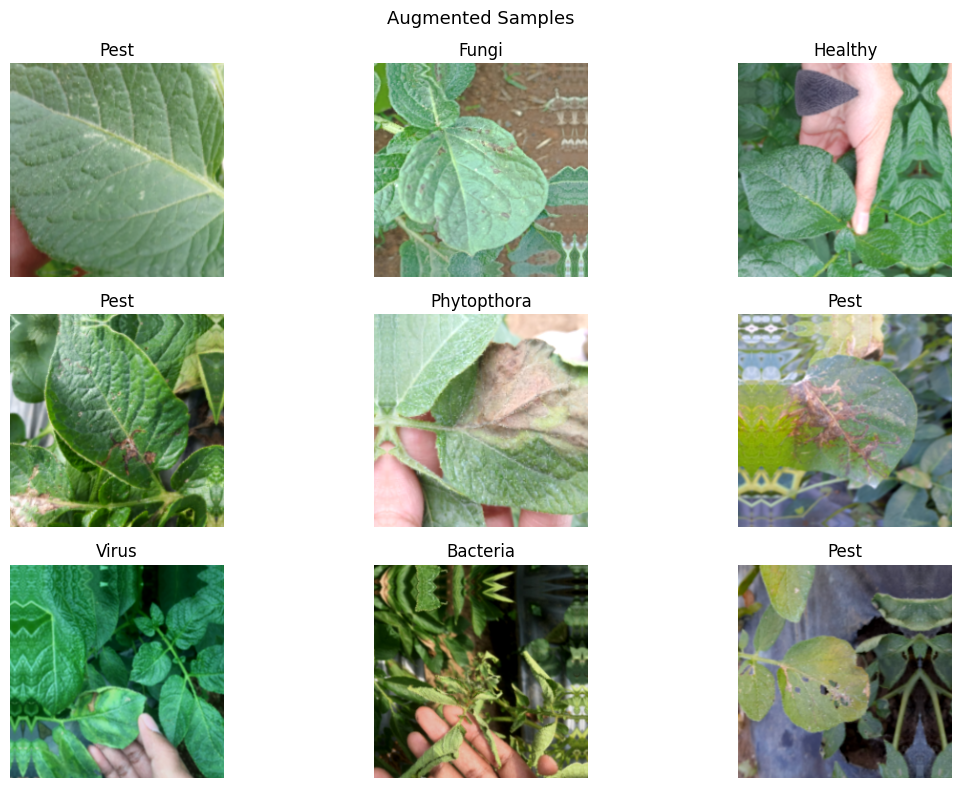

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.20),
    tf.keras.layers.RandomZoom(0.20),
    tf.keras.layers.RandomTranslation(0.15, 0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
], name="data_augmentation")

# Preview augmented samples
for images, labels in training_set.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(min(9, len(images))):
        aug = data_augmentation(tf.expand_dims(images[i], 0), training=True)
        plt.subplot(3, 3, i + 1)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title(class_names[tf.argmax(labels[i]).numpy()])
        plt.axis('off')
    plt.suptitle('Augmented Samples', fontsize=13)
    plt.tight_layout(); plt.show()

## Step 6: Build Model — EfficientNetB0 Transfer Learning

In [11]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))

# Data augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing (optional for EfficientNet,
# included for code clarity/future portability)
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Classification head
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Phase 1: Train Classifier Head

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LR,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

callbacks = [

    # Stop when validation loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate automatically
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3166 - loss: 2.4467 - precision: 0.3762 - recall: 0.2220
Epoch 1: val_loss improved from None to 1.48680, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 355ms/step - accuracy: 0.3929 - loss: 2.1014 - precision: 0.4628 - recall: 0.2930 - val_accuracy: 0.5114 - val_loss: 1.4868 - val_precision: 0.6154 - val_recall: 0.0784 - learning_rate: 0.0010
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4752 - loss: 1.7218 - precision: 0.5492 - recall: 0.3829
Epoch 2: val_loss improved from 1.48680 to 1.37441, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.4805 - loss: 1.6949 - precision: 0.5538 - recall: 0.3888 - val_accuracy: 0.5588 - val_loss: 1.3744 - val_precision: 0.7378 - val_recall: 0.2712 - learning_rate: 0.0010
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━

## Training History

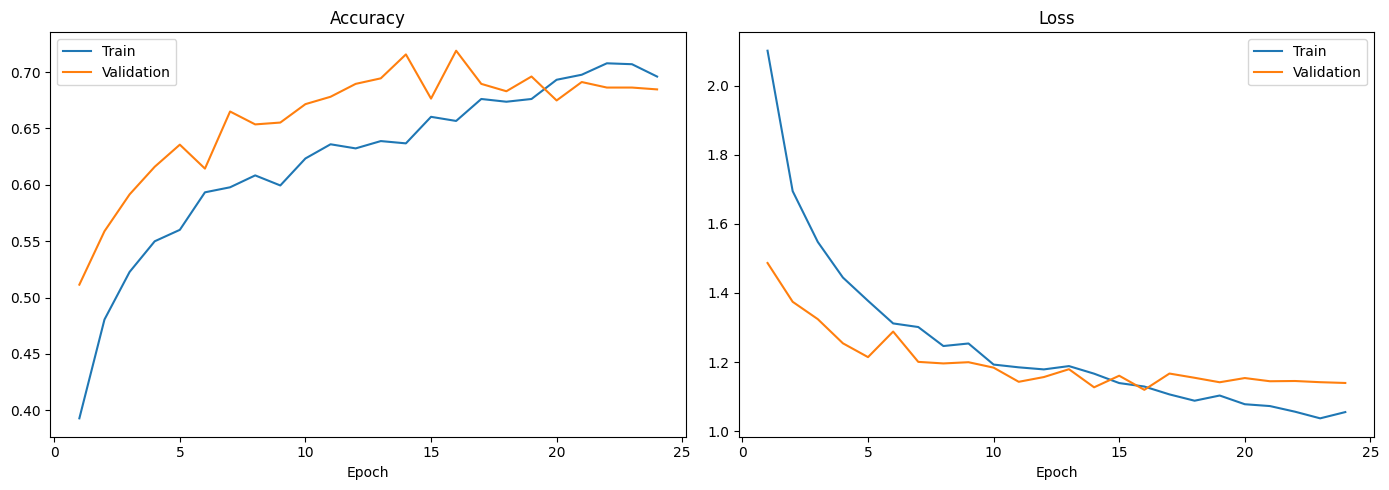

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tr, vl, title in zip(
    axes,
    [acc, loss],
    [val_acc, val_loss],
    ['Accuracy', 'Loss']
):
    ax.plot(epochs_range, tr, label='Train')
    ax.plot(epochs_range, vl, label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

with open('training_hist.json', 'w') as f:
    json.dump({
        'accuracy': acc,
        'val_accuracy': val_acc,
        'loss': loss,
        'val_loss': val_loss
    }, f)

## Final Evaluation

In [14]:
model = tf.keras.models.load_model('best_model.keras')

# For evaluation: batch_size=1, shuffle=False, same val folder
eval_set = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    labels='inferred', label_mode='categorical',
    color_mode='rgb', batch_size=1,
    image_size=IMAGE_SIZE, shuffle=False
)

y_pred = model.predict(eval_set, verbose=1)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for _, y in eval_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

print('\nClassification Report')
print(classification_report(Y_true, predicted_categories,
      target_names=class_names, zero_division=0))

Found 612 files belonging to 7 classes.
612/612 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step

Classification Report
              precision    recall  f1-score   support

    Bacteria       0.95      0.92      0.93       113
       Fungi       0.70      0.68      0.69       149
     Healthy       0.43      0.90      0.59        40
    Nematode       0.73      0.85      0.79        13
        Pest       0.63      0.68      0.65       122
 Phytopthora       0.77      0.72      0.75        69
       Virus       0.89      0.52      0.65       106

    accuracy                           0.72       612
   macro avg       0.73      0.75      0.72       612
weighted avg       0.75      0.72      0.72       612



## Confusion Matrix

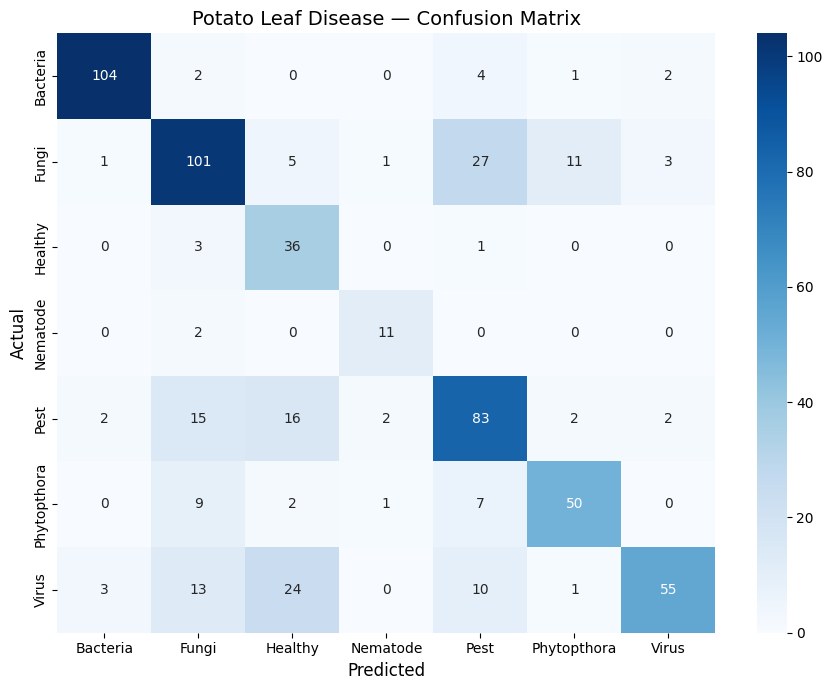

In [15]:
cm = confusion_matrix(Y_true, predicted_categories)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Potato Leaf Disease — Confusion Matrix', fontsize=14)
plt.tight_layout(); plt.show()

## Save Model

In [16]:
model.save('trained_potato_disease_model_efficientnet.keras')
print('Saved: trained_potato_disease_model_efficientnet.keras')

Saved: trained_potato_disease_model_efficientnet.keras


## Single Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


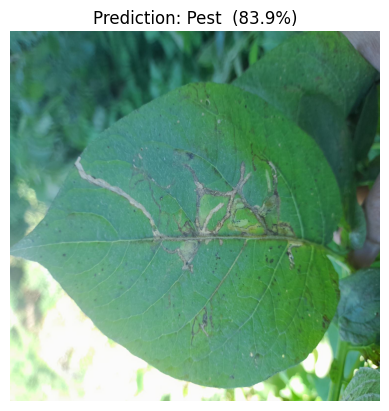

In [19]:
import cv2

# image_path = os.path.join(SPLIT_DIR, 'val', class_names[0],
#                            os.listdir(os.path.join(SPLIT_DIR, 'val', class_names[0]))[0])
image_path = "/content/potato_split/val/Pest/20230712_122034.jpg"
img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
inp = tf.keras.preprocessing.image.img_to_array(
      tf.keras.preprocessing.image.load_img(image_path, target_size=IMAGE_SIZE))
inp = np.expand_dims(inp, axis=0)

preds      = model.predict(inp)
idx        = np.argmax(preds)
confidence = preds[0][idx] * 100

plt.imshow(img)
plt.title(f'Prediction: {class_names[idx]}  ({confidence:.1f}%)')
plt.axis('off'); plt.show()